# 🛒 Superstore Sales Analysis & Preprocessing
**Dataset:** Sample Superstore | 9,994 transaksi | 2014–2017  
**Tujuan:** Membersihkan dan mempersiapkan data mentah untuk analisis KPI dashboard
dan pemodelan machine learning prediksi penjualan.

In [1]:
# ── CELL 1: Import & Load ──────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2014,1
9990,9991,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2017,2
9991,9992,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2017,2
9992,9993,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2017,2


In [6]:
# ── CELL 2: Aggregasi Bulanan ──────────────────────────
monthly = df.groupby(['Year','Month']).agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Quantity=('Quantity','sum'),
    Avg_Discount=('Discount','mean'),
    Num_Orders=('Order ID','nunique')
).reset_index().sort_values(['Year','Month']).reset_index(drop=True)

monthly

,Year,Month,Sales,Profit,Quantity,Avg_Discount,Num_Orders
0,2014,1,14236.8950,2450.1907,284,0.126582,32
1,2014,2,4519.8920,862.3084,159,0.176087,28
2,2014,3,55691.0090,498.7299,585,0.167516,71
3,2014,4,28295.3450,3488.8352,536,0.110000,66
4,2014,5,23648.2870,2738.7096,466,0.155328,69
5,2014,6,34595.1276,4976.5244,521,0.172000,66
6,2014,7,33946.3930,-841.4826,550,0.171678,65
7,2014,8,27909.4685,5318.1050,609,0.131046,72
8,2014,9,81777.3508,8328.0994,1000,0.159963,130
9,2014,10,31453.3930,3448.2573,573,0.160063,78


In [7]:
# ── CELL 3: Feature Engineering ───────────────────────
for lag in [1, 2, 3]:
    monthly[f'Sales_Lag{lag}'] = monthly['Sales'].shift(lag)
monthly['Sales_Rolling3'] = monthly['Sales'].rolling(3).mean().shift(1)
monthly['Sales_Rolling6'] = monthly['Sales'].rolling(6).mean().shift(1)
monthly = monthly.dropna().reset_index(drop=True)

monthly

,Year,Month,Sales,Profit,Quantity,Avg_Discount,Num_Orders,Sales_Lag1,Sales_Lag2,Sales_Lag3,Sales_Rolling3,Sales_Rolling6
0,2014,7,33946.3930,-841.4826,550,0.171678,65,34595.1276,23648.2870,28295.3450,28846.253200,26831.092600
1,2014,8,27909.4685,5318.1050,609,0.131046,72,33946.3930,34595.1276,23648.2870,30729.935867,30116.008933
2,2014,9,81777.3508,8328.0994,1000,0.159963,130,27909.4685,33946.3930,34595.1276,32150.329700,34014.271683
3,2014,10,31453.3930,3448.2573,573,0.160063,78,81777.3508,27909.4685,33946.3930,47877.737433,38361.995317
4,2014,11,78628.7167,9292.1269,1219,0.151164,151,31453.3930,81777.3508,27909.4685,47046.737433,38888.336650
5,2014,12,69545.6205,8983.5699,1079,0.190827,141,78628.7167,31453.3930,81777.3508,63953.153500,48051.741600
6,2015,1,18174.0756,-3281.0070,236,0.177931,29,69545.6205,78628.7167,31453.3930,59875.910067,53876.823750
7,2015,2,11951.4110,2813.8508,239,0.129688,36,18174.0756,69545.6205,78628.7167,55449.470933,51248.104183
8,2015,3,38726.2520,9732.0978,515,0.140145,79,11951.4110,18174.0756,69545.6205,33223.702367,48588.427933
9,2015,4,34195.2085,4187.4962,543,0.175938,72,38726.2520,11951.4110,18174.0756,22950.579533,41413.244800


In [8]:
# ── CELL 4: Train/Test Split & Modelling ──────────────
features = ['Month','Quantity','Avg_Discount','Num_Orders',
            'Sales_Lag1','Sales_Lag2','Sales_Lag3',
            'Sales_Rolling3','Sales_Rolling6']
X = monthly[features]
y = monthly['Sales']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{name}: R²={r2_score(y_test,pred):.3f} | MAE={mean_absolute_error(y_test,pred):.0f}")

Linear Regression: R²=0.661 | MAE=12212
Random Forest: R²=0.577 | MAE=12759
Gradient Boosting: R²=0.618 | MAE=12744


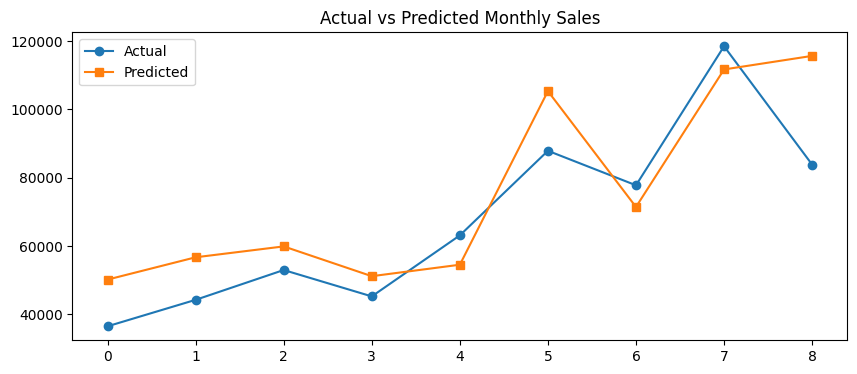

In [9]:
# ── CELL 5: Visualisasi Actual vs Predicted ───────────
best_model = LinearRegression().fit(X_train, y_train)
pred = best_model.predict(X_test)
plt.figure(figsize=(10,4))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(pred, label='Predicted', marker='s')
plt.title('Actual vs Predicted Monthly Sales'); plt.legend()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')